In [7]:
# %%
import os, sys, warnings
warnings.filterwarnings("ignore")

# Route to project root regardless of where you open the notebook
if os.getcwd().endswith(("notebook", "notebooks")):
    os.chdir("..")
sys.path.insert(0, os.path.abspath("."))

# Force-reload the module every time (helpful during development)
if "src.sentiment_analysis" in sys.modules:
    del sys.modules["src.sentiment_analysis"]

from src.sentiment_analysis import (
    modular_nlp_pipeline,        # text pre-processing
    preprocess_for_nlp,          # alias — same function
    sia,                         # VADER instance
    get_vader_label,             # compound → label
    classify_hf_local,           # HF pipeline wrapper  ← BUG FIXED
    classify_review_sentiment,   # VADER-only one-liner  ← was missing
    run_full_sentiment_pipeline, # convenience wrapper
    aggregate_by_bank_and_rating,
    plot_sentiment_dashboard,
)
import pandas as pd

print("Imports OK ✓")

Imports OK ✓


In [8]:
# %%
df_raw = pd.read_csv("data/processed/all_banks_combined_clean.csv")
print(f"Loaded {len(df_raw):,} rows | columns: {df_raw.columns.tolist()}")

Loaded 1,800 rows | columns: ['review', 'rating', 'date', 'bank', 'source']


In [9]:
# %%
from transformers import pipeline as hf_pipeline

print("Loading DistilBERT …")
classifier = hf_pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512,
    token=False,
)
print("Model ready ✓")

Loading DistilBERT …


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model ready ✓


In [10]:
# %%
df_clean = run_full_sentiment_pipeline(
    df_raw,
    classifier,
    text_col="review",
    bank_col="bank",
    rating_col="rating",
)

print("Column preview:")
print(df_clean[["bank", "rating", "vader_compound", "vader_sentiment",
                "hf_sentiment", "hf_directional_score"]].head(10).to_string())

Step 1/3  Pre-processing text …
Step 2/3  VADER scoring …
Step 3/3  DistilBERT scoring …

Done. Final dataset: 1,664 rows.

Column preview:
                          bank  rating  vader_compound vader_sentiment hf_sentiment  hf_directional_score
0  Commercial Bank of Ethiopia       5          0.6369        positive     POSITIVE              0.999166
1  Commercial Bank of Ethiopia       5          0.4404        positive     POSITIVE              0.999866
2  Commercial Bank of Ethiopia       5          0.3612        positive     POSITIVE              0.999756
3  Commercial Bank of Ethiopia       5          0.4404        positive     POSITIVE              0.999839
4  Commercial Bank of Ethiopia       5          0.5859        positive     POSITIVE              0.999592
5  Commercial Bank of Ethiopia       2          0.4404        positive     POSITIVE              0.999855
6  Commercial Bank of Ethiopia       5          0.5927        positive     NEGATIVE             -0.987926
7  Commercia

In [11]:
# %%
print("=== VADER distribution ===")
print(df_clean["vader_sentiment"].value_counts(normalize=True).round(3).to_string())

print("\n=== DistilBERT distribution ===")
print(df_clean["hf_sentiment"].value_counts(normalize=True).round(3).to_string())

=== VADER distribution ===
vader_sentiment
positive    0.628
neutral     0.225
negative    0.147

=== DistilBERT distribution ===
hf_sentiment
POSITIVE    0.638
NEGATIVE    0.362


In [12]:
# %%
agg = aggregate_by_bank_and_rating(df_clean)

print("Mean VADER compound by bank:")
print(agg["vader_by_bank"].to_string())

print("\nMean DistilBERT score by bank:")
print(agg["hf_by_bank"].to_string())

print("\nMean VADER compound by star rating:")
print(agg["vader_by_rating"].to_string())

print("\nMean DistilBERT score by star rating:")
print(agg["hf_by_rating"].to_string())

print("\nDistilBERT label proportions by bank:")
display(agg["hf_dist_by_bank"])

Mean VADER compound by bank:
bank
Bank of Abyssinia              0.1785
Commercial Bank of Ethiopia    0.2916
Dashen Bank                    0.3077

Mean DistilBERT score by bank:
bank
Bank of Abyssinia              0.1003
Commercial Bank of Ethiopia    0.4076
Dashen Bank                    0.3306

Mean VADER compound by star rating:
rating
1   -0.1446
2    0.0742
3    0.1365
4    0.3173
5    0.4186

Mean DistilBERT score by star rating:
rating
1   -0.7426
2   -0.6417
3   -0.2906
4    0.2070
5    0.7573

DistilBERT label proportions by bank:


hf_sentiment,NEGATIVE,POSITIVE
bank,,
Bank of Abyssinia,0.4508,0.5492
Commercial Bank of Ethiopia,0.2980,0.7020
Dashen Bank,0.3351,0.6649


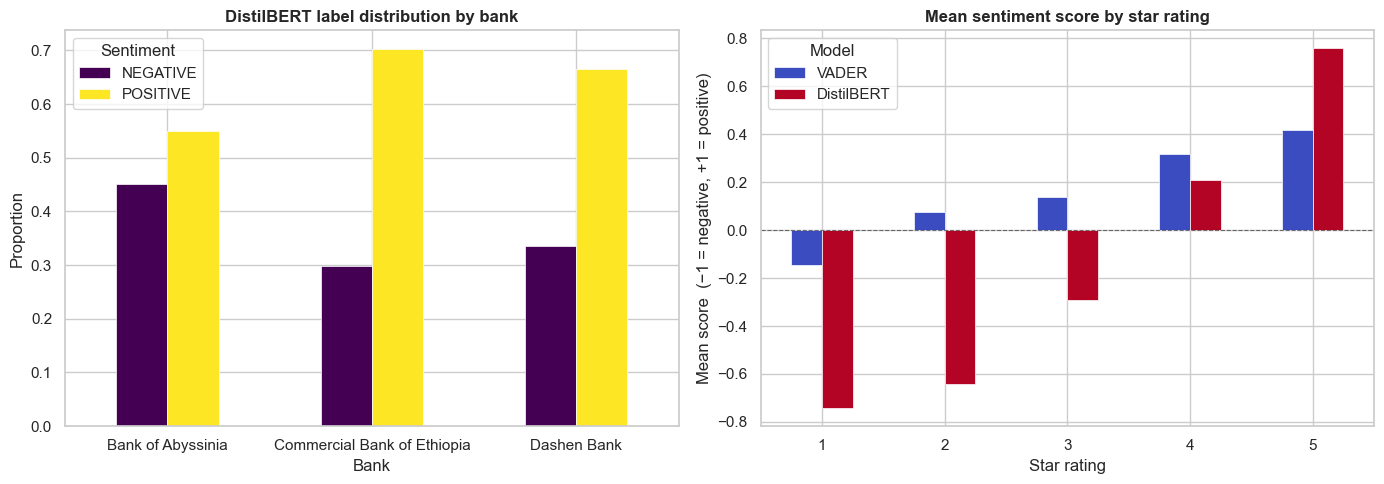

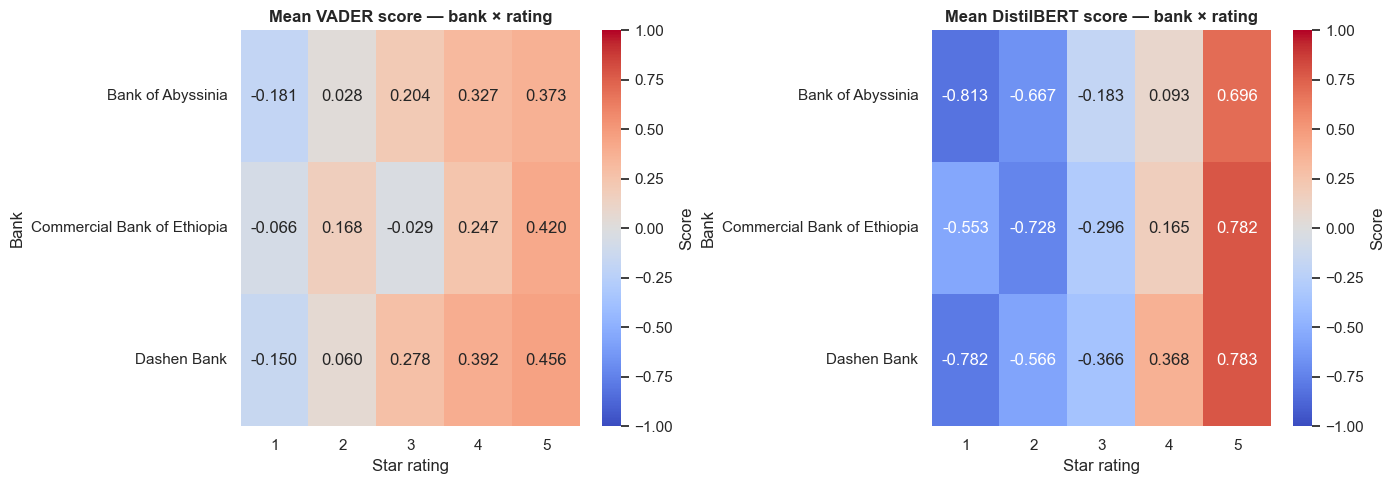

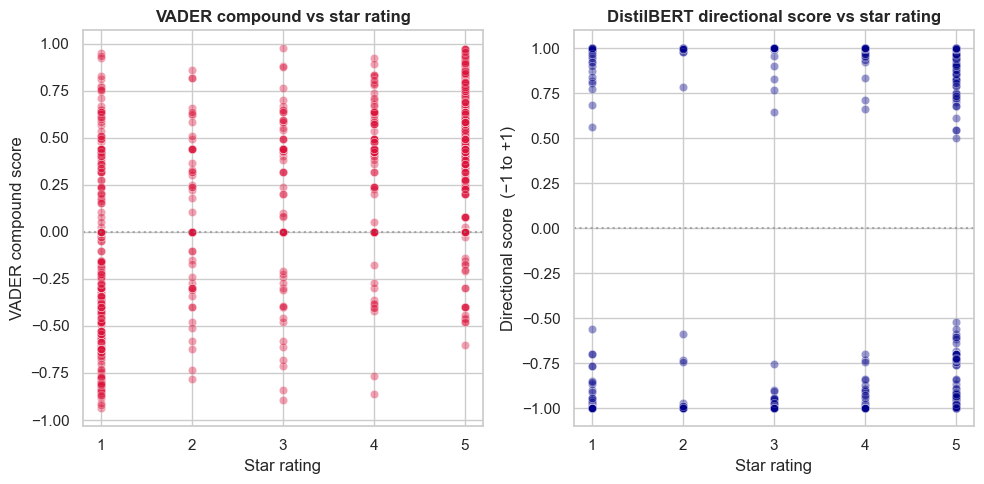

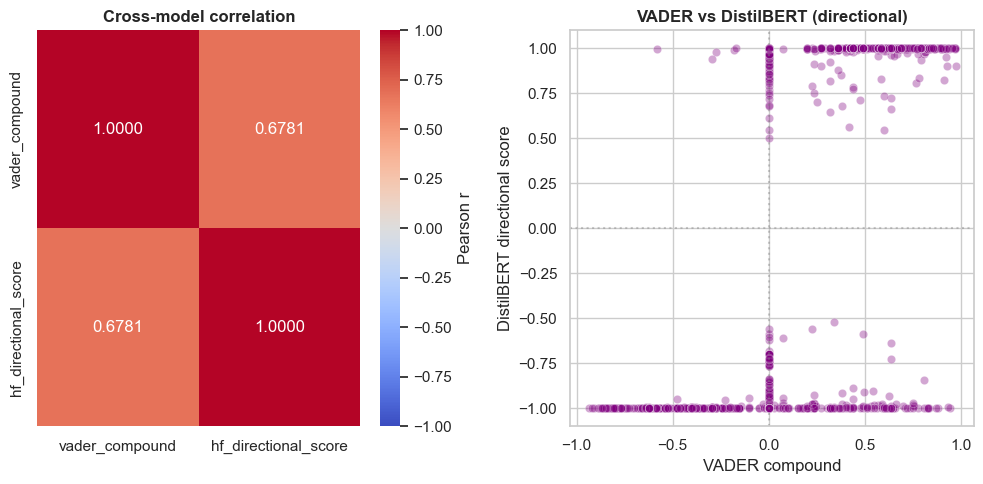


=== Summary tables ===

Mean VADER compound by bank:
bank
Bank of Abyssinia              0.1785
Commercial Bank of Ethiopia    0.2916
Dashen Bank                    0.3077

Mean DistilBERT directional score by bank:
bank
Bank of Abyssinia              0.1003
Commercial Bank of Ethiopia    0.4076
Dashen Bank                    0.3306

Mean VADER compound by star rating:
rating
1   -0.1446
2    0.0742
3    0.1365
4    0.3173
5    0.4186

Mean DistilBERT directional score by star rating:
rating
1   -0.7426
2   -0.6417
3   -0.2906
4    0.2070
5    0.7573


In [13]:
# %%
plot_sentiment_dashboard(df_clean)

In [26]:
# %%
out_path = "data/processed/all_banks_sentiment.csv"
df_clean.to_csv(out_path, index=False)
print(f"Saved → {out_path}  ({len(df_clean):,} rows)")

Saved → data/processed/all_banks_sentiment.csv  (1,664 rows)


thematic analysis

In [15]:
import os, sys, warnings
warnings.filterwarnings("ignore")

if os.getcwd().endswith(("notebook", "notebooks")):
    os.chdir("..")
sys.path.insert(0, os.path.abspath("."))

# Force-reload during development
for mod in ["src.thematic_analysis", "src.sentiment_analysis"]:
    if mod in sys.modules:
        del sys.modules[mod]

from src.thematic_analysis import (
    THEME_MAP, THEME_COLORS,
    assign_themes, explode_themes,
    extract_keywords_tfidf, extract_top_ngrams,
    run_lda,
    plot_themes_per_bank, plot_theme_sentiment,
    plot_lda_topics, plot_keyword_heatmap,
    plot_wordcloud_per_bank, plot_ngram_comparison,
    plot_theme_count_grid, run_full_thematic_pipeline,
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Imports OK ✓")

Imports OK ✓


In [16]:
# Prefer the sentiment-enriched file; fall back to the raw cleaned CSV
try:
    df = pd.read_csv("data/processed/all_banks_sentiment.csv")
    print("Loaded sentiment-enriched dataset.")
except FileNotFoundError:
    df = pd.read_csv("data/processed/all_banks_combined_clean.csv")
    print("Loaded base cleaned dataset (no sentiment columns).")

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Banks:   {df['bank'].unique().tolist()}")

Loaded base cleaned dataset (no sentiment columns).
Shape: (1800, 5)
Columns: ['review', 'rating', 'date', 'bank', 'source']
Banks:   ['Commercial Bank of Ethiopia', 'Bank of Abyssinia', 'Dashen Bank']


In [17]:
# Print the full THEME_MAP for reference
for theme, keywords in THEME_MAP.items():
    print(f"\n  {theme:28s}: {', '.join(keywords[:8])} …")


  Account Access              : login, log, signin, sign, otp, password, pasword, verify …

  Transaction Performance     : transfer, send, receive, payment, pay, transaction, delay, slow …

  App Stability               : crash, crashing, freeze, frozen, bug, error, glitch, problem …

  UI & Design                 : ui, interface, design, layout, navigation, menu, button, easy …

  Customer Support            : support, service, customer, help, response, agent, call, hotline …

  Feature Requests            : feature, request, add, wish, want, need, missing, please …


In [18]:
print("Assigning themes …")
df["themes"] = df["review"].apply(assign_themes)

print(f"\nTheme value counts (raw multi-label):")
print(df["themes"].value_counts().head(15).to_string())

# Exploded (one row per theme) for analytics
df_exploded = explode_themes(df)
print(f"\nAfter exploding: {len(df_exploded):,} rows  |  unique themes: "
      f"{df_exploded['themes'].nunique()}")

Assigning themes …

Theme value counts (raw multi-label):
themes
Other                                                       1178
Transaction Performance                                      148
App Stability                                                 79
UI & Design                                                   62
Feature Requests                                              33
Transaction Performance, UI & Design                          31
App Stability, Feature Requests                               29
Customer Support                                              28
Transaction Performance, App Stability                        28
Account Access, App Stability                                 15
Transaction Performance, App Stability, Feature Requests      13
Account Access, Transaction Performance                       13
Account Access                                                13
Transaction Performance, Feature Requests                     12
Transaction Performance, 

In [20]:
# Safety Check: Generate 'clean_text' if it is missing
if "clean_text" not in df.columns:
    print("Column 'clean_text' not found. Generating it now... (this may take a few seconds)")
    df["clean_text"] = df["review"].apply(modular_nlp_pipeline)
    print("Done! 'clean_text' is ready.")
else:
    print("'clean_text' is already present.")

Column 'clean_text' not found. Generating it now... (this may take a few seconds)
Done! 'clean_text' is ready.


In [21]:
print("Extracting TF-IDF keywords per bank …\n")
kw_df = extract_keywords_tfidf(df, text_col="clean_text", bank_col="bank",
                                top_n=12)
display(kw_df)

print("\n=== Full keyword list ===")
for bank, row in kw_df.iterrows():
    print(f"\n  {bank}")
    print(f"    Keywords : {row['Top Keywords']}")
    print(f"    Phrases  : {row['Top Phrases']}")

Extracting TF-IDF keywords per bank …



,Top Keywords,Top Phrases
Bank,,
Bank of Abyssinia,"good, app, best, nice, bank, boa, work, bankin...","mobile banking, good app, best app, banking ap..."
Commercial Bank of Ethiopia,"good, app, nice, best, cbe, application, like,...","nice app, good app, best app, easy use, good a..."
Dashen Bank,"app, good, best, nice, bank, dashen, super, us...","nice app, dashen bank, super app, best app, go..."



=== Full keyword list ===

  Bank of Abyssinia
    Keywords : good, app, best, nice, bank, boa, work, banking, worst, working, mobile, use
    Phrases  : mobile banking, good app, best app, banking app, worst app, mobile app, boa mobile, nice app, developer option, app work, use app, app working

  Commercial Bank of Ethiopia
    Keywords : good, app, nice, best, cbe, application, like, bank, service, use, working, update
    Phrases  : nice app, good app, best app, easy use, good application, good service, mobile banking, excellent app, good job, great app, good work, update app

  Dashen Bank
    Keywords : app, good, best, nice, bank, dashen, super, use, great, fast, easy, banking
    Phrases  : nice app, dashen bank, super app, best app, good app, great app, easy use, mobile banking, banking app, worst app, amazing app, app used


Plotting bigrams per bank …


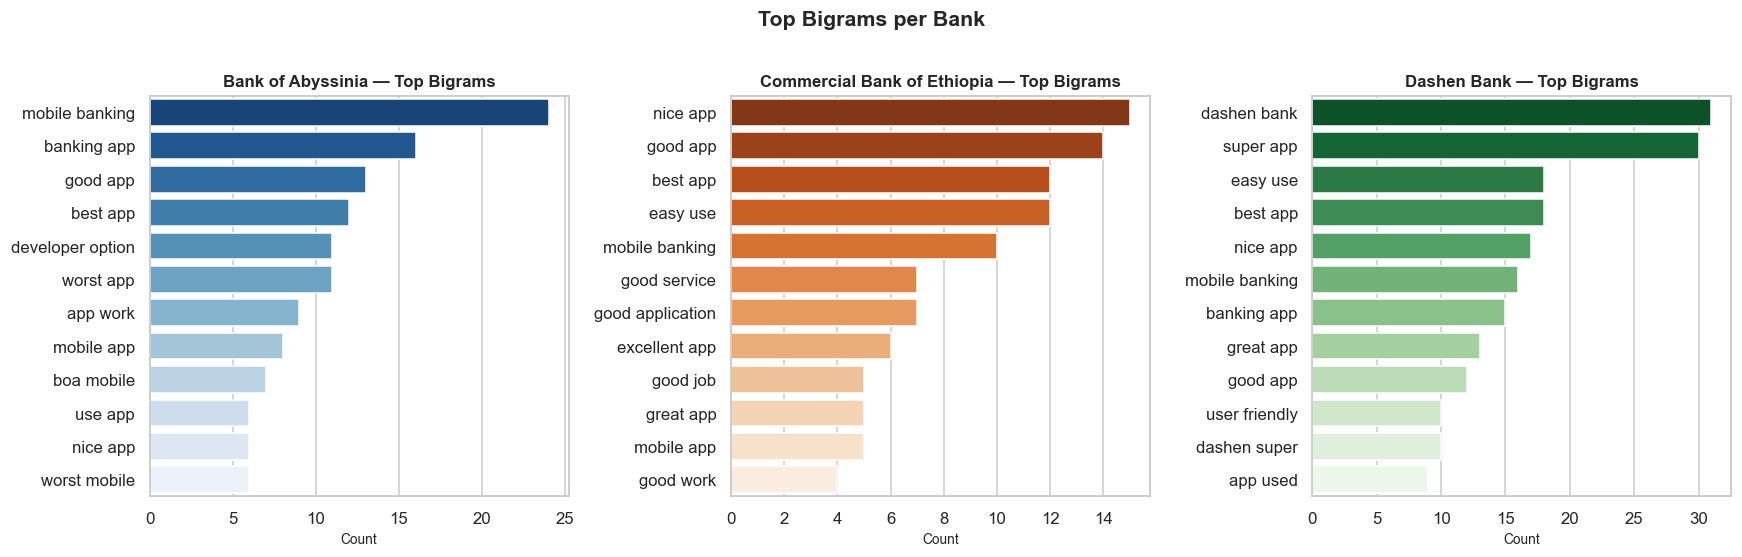

Plotting trigrams per bank …


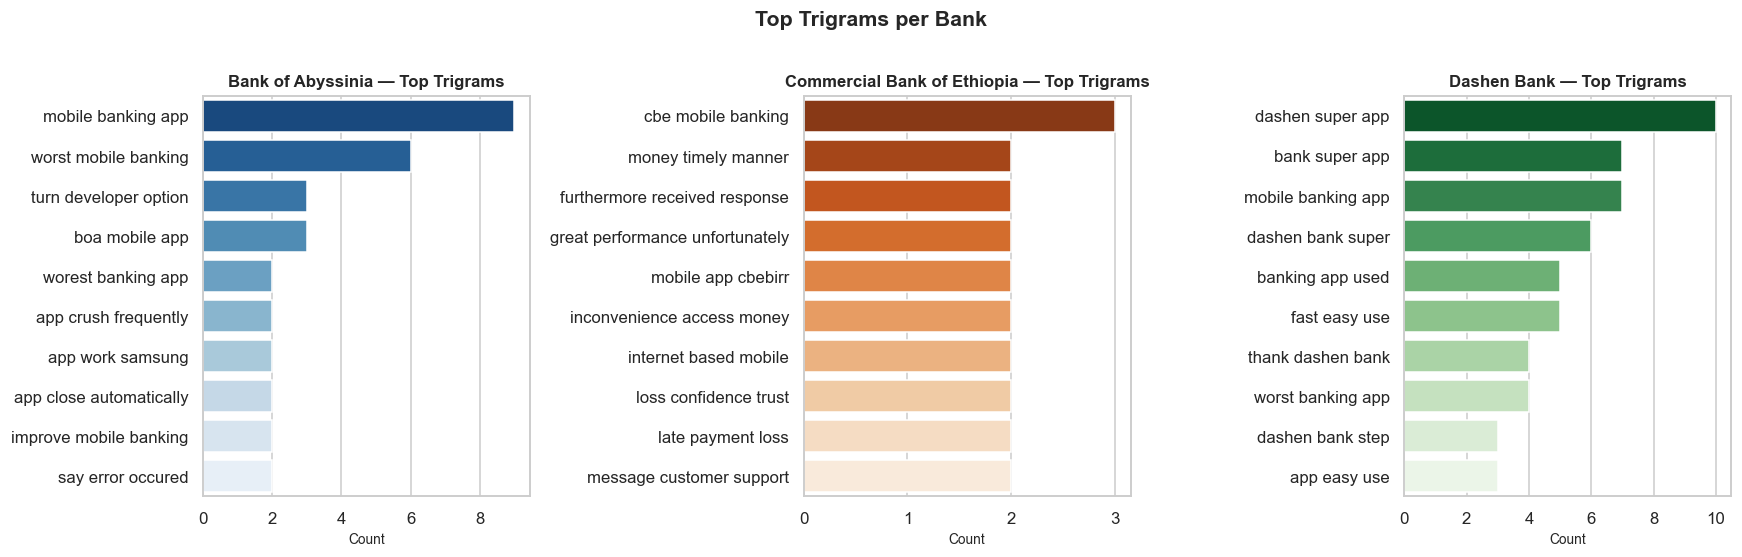

In [22]:
print("Plotting bigrams per bank …")
plot_ngram_comparison(df, text_col="clean_text", bank_col="bank", n=2, top_k=12)

print("Plotting trigrams per bank …")
plot_ngram_comparison(df, text_col="clean_text", bank_col="bank", n=3, top_k=10)

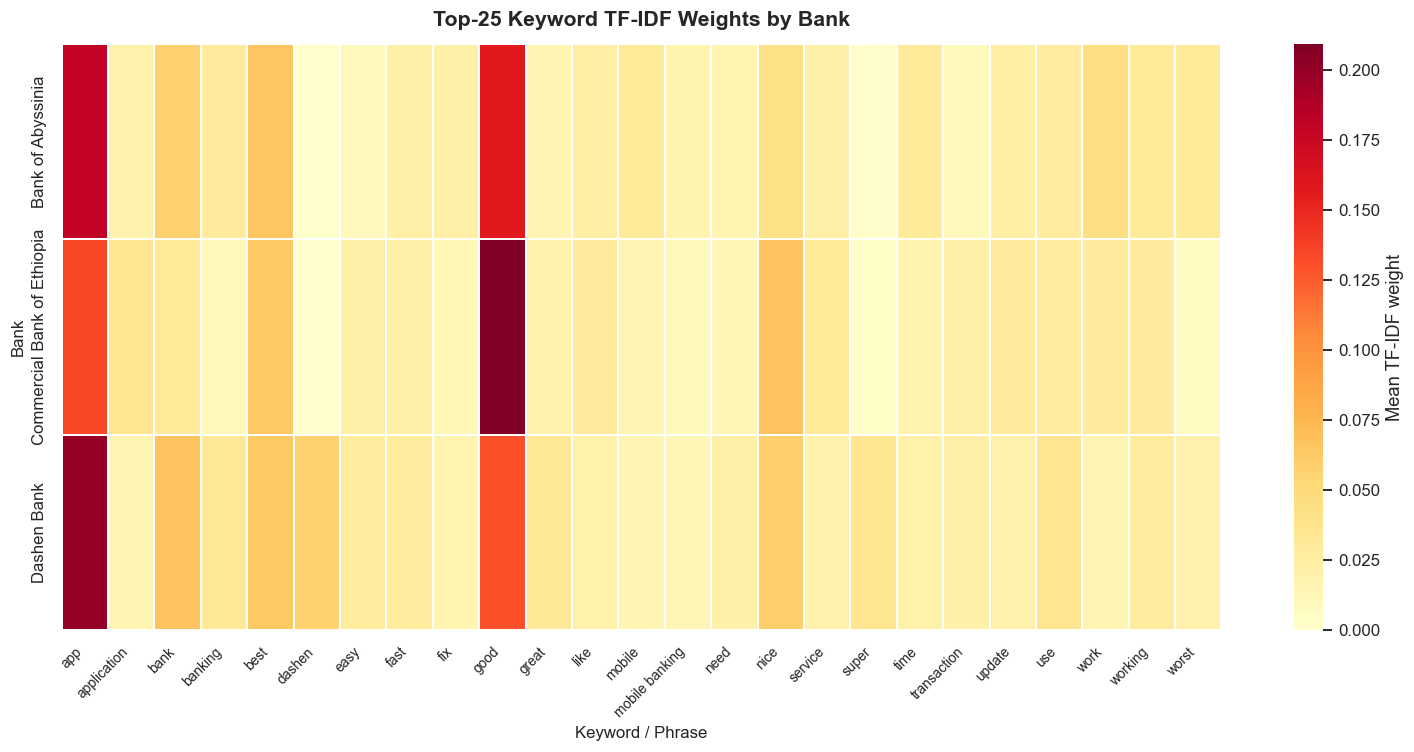

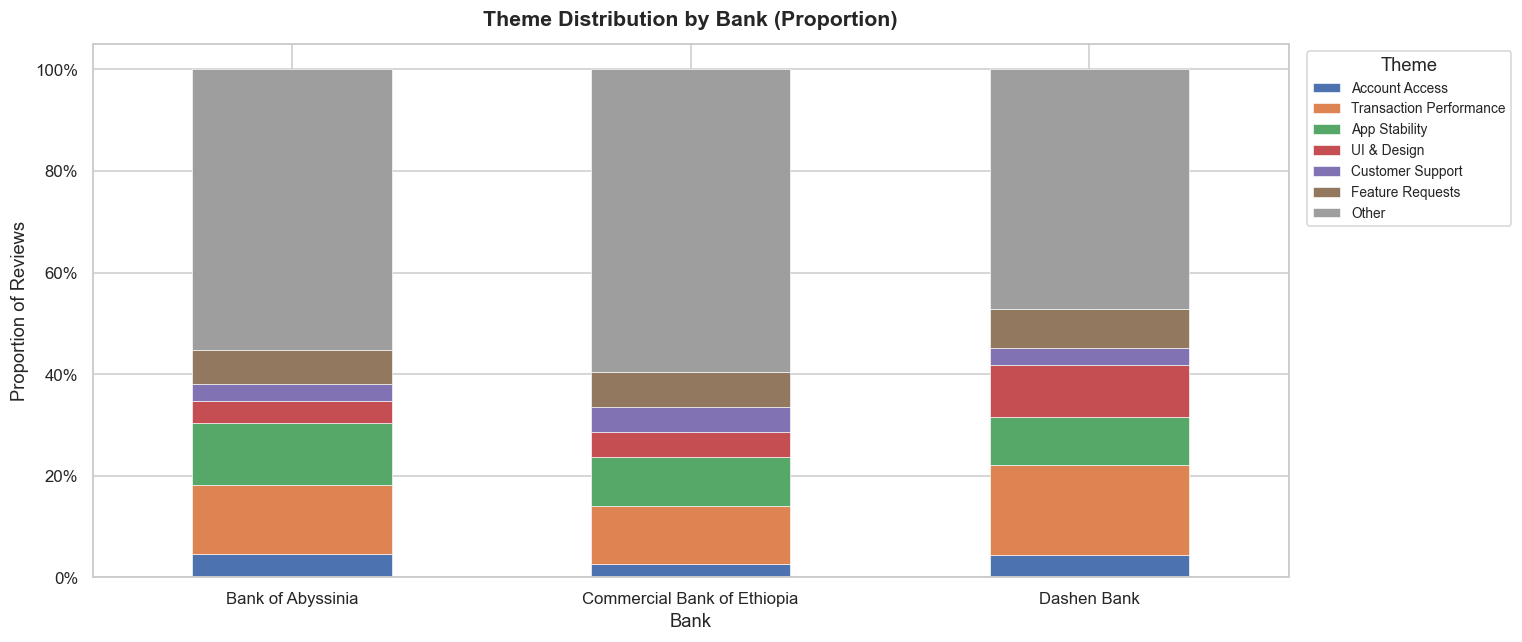


=== Theme proportions per bank ===
themes                       Account Access  Transaction Performance  App Stability  UI & Design  Customer Support  Feature Requests   Other
bank                                                                                                                                        
Bank of Abyssinia                    0.0459                   0.1349         0.1238       0.0431            0.0320            0.0668  0.5535
Commercial Bank of Ethiopia          0.0257                   0.1141         0.0970       0.0485            0.0499            0.0685  0.5963
Dashen Bank                          0.0443                   0.1773         0.0939       0.1030            0.0326            0.0769  0.4720


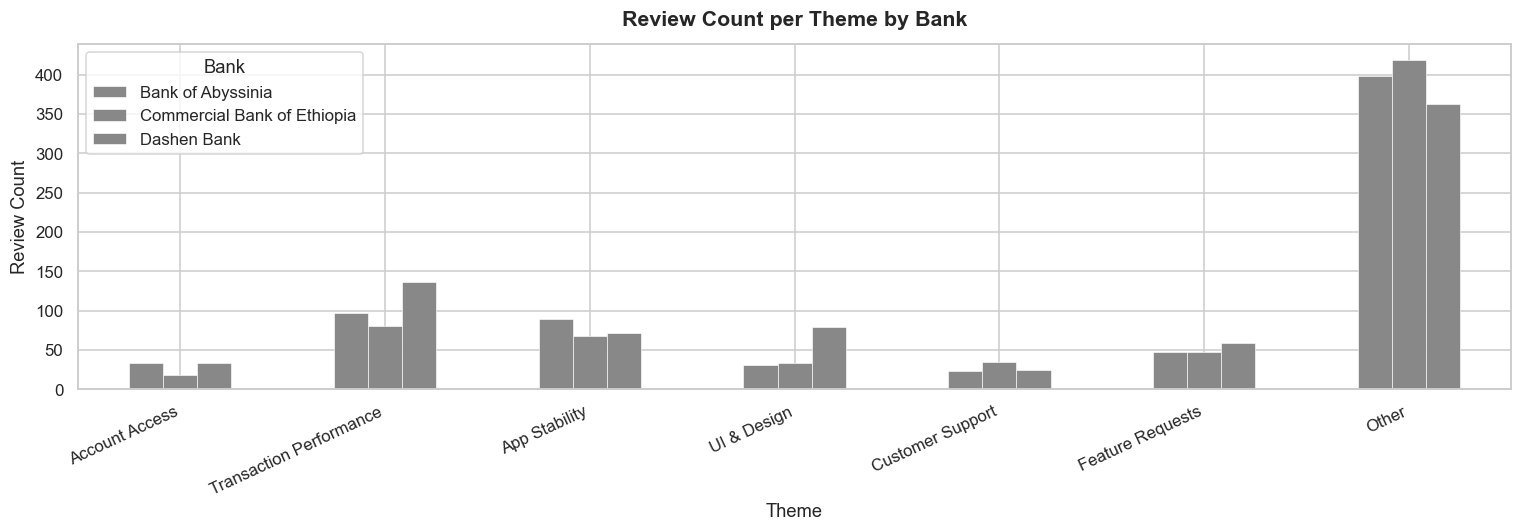

In [23]:
plot_keyword_heatmap(df, text_col="clean_text", bank_col="bank", top_n=25)
plot_themes_per_bank(df, theme_col="themes", bank_col="bank")
plot_theme_count_grid(df, theme_col="themes", bank_col="bank")

In [30]:
# Emergency Fix: Generate the missing 'themes' column and 'df_exploded'
if "themes" not in df.columns:
    print("Assigning themes to the dataset...")
    df["themes"] = df["review"].apply(assign_themes)
    
    # We also need to recreate df_exploded for your tables to work!
    df_exploded = explode_themes(df)
    print("Done! The 'themes' column is now ready.")
else:
    print("Themes are already assigned!")

Assigning themes to the dataset...
Done! The 'themes' column is now ready.


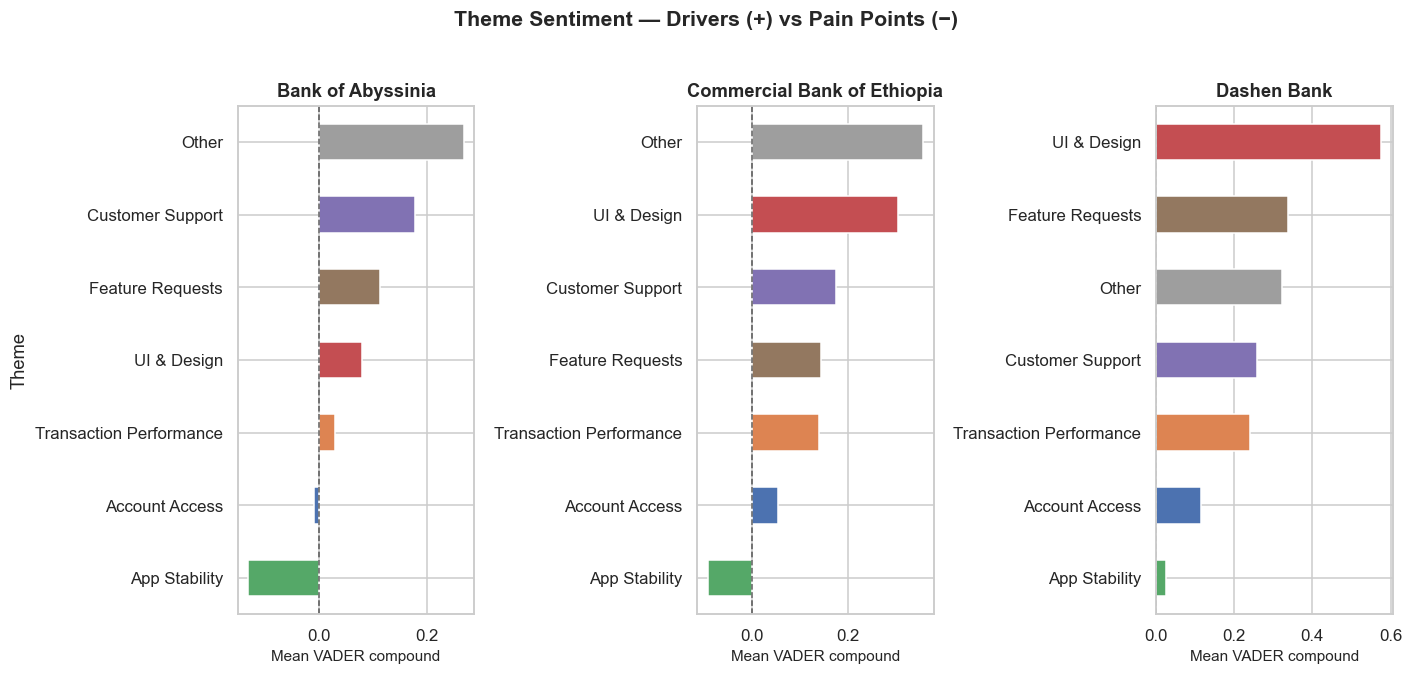


=== Mean VADER score by bank and theme ===


,bank,themes,mean_vader,n_reviews
1,Bank of Abyssinia,App Stability,-0.1312,89
0,Bank of Abyssinia,Account Access,-0.0092,33
5,Bank of Abyssinia,Transaction Performance,0.0299,97
6,Bank of Abyssinia,UI & Design,0.0785,31
3,Bank of Abyssinia,Feature Requests,0.1120,48
2,Bank of Abyssinia,Customer Support,0.1778,23
4,Bank of Abyssinia,Other,0.2674,357
8,Commercial Bank of Ethiopia,App Stability,-0.0912,68
7,Commercial Bank of Ethiopia,Account Access,0.0557,18
12,Commercial Bank of Ethiopia,Transaction Performance,0.1399,80


In [31]:
if "vader_compound" in df.columns:
    plot_theme_sentiment(df, theme_col="themes",
                          sentiment_col="vader_compound", bank_col="bank")

    # Aggregate table
    theme_sent_agg = (
        df_exploded
        .groupby(["bank", "themes"])["vader_compound"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "mean_vader", "count": "n_reviews"})
        .round(4)
        .reset_index()
        .sort_values(["bank", "mean_vader"])
    )
    print("\n=== Mean VADER score by bank and theme ===")
    display(theme_sent_agg)
else:
    print("[Skipped] vader_compound column not found — run Task 2 first.")

In [32]:
if "vader_compound" in df.columns:
    print("=" * 55)
    for bank in sorted(df["bank"].unique()):
        sub = df_exploded[df_exploded["bank"] == bank]
        agg = sub.groupby("themes")["vader_compound"].mean().sort_values()

        print(f"\n  {bank.upper()}")
        print(f"    Pain Points (lowest score):  "
              f"{agg.index[0]}  ({agg.iloc[0]:.3f})")
        print(f"    Driver (highest score):      "
              f"{agg.index[-1]}  ({agg.iloc[-1]:.3f})")
    print("=" * 55)


  BANK OF ABYSSINIA
    Pain Points (lowest score):  App Stability  (-0.131)
    Driver (highest score):      Other  (0.267)

  COMMERCIAL BANK OF ETHIOPIA
    Pain Points (lowest score):  App Stability  (-0.091)
    Driver (highest score):      Other  (0.355)

  DASHEN BANK
    Pain Points (lowest score):  App Stability  (0.026)
    Driver (highest score):      UI & Design  (0.577)


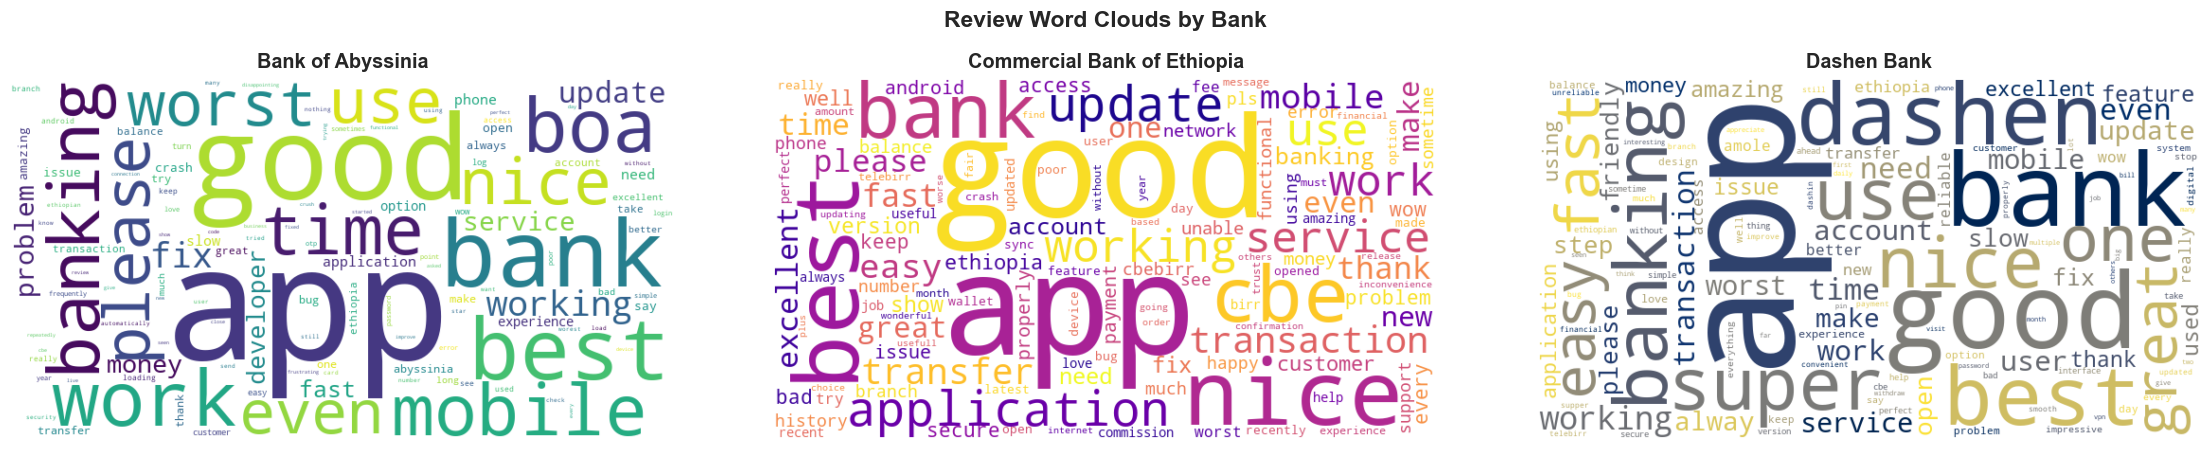

In [33]:
plot_wordcloud_per_bank(df, text_col="clean_text", bank_col="bank")

Running LDA …

=== LDA top words per topic ===


,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5
0,app,app,use,good,best,nice
1,banking,working,application,app,app,slow
2,work,account,fix,great,bank,apps
3,mobile,excellent,service,design,like,amazing
4,bank,update,ethiopia,user,worst,thank
5,dashen,problem,easy,ahead,issue,bad
6,fast,open,wow,interface,option,transaction
7,super,transfer,time,response,developer,feature
8,time,love,customer,supper,say,need
9,use,money,bug,language,transaction,like


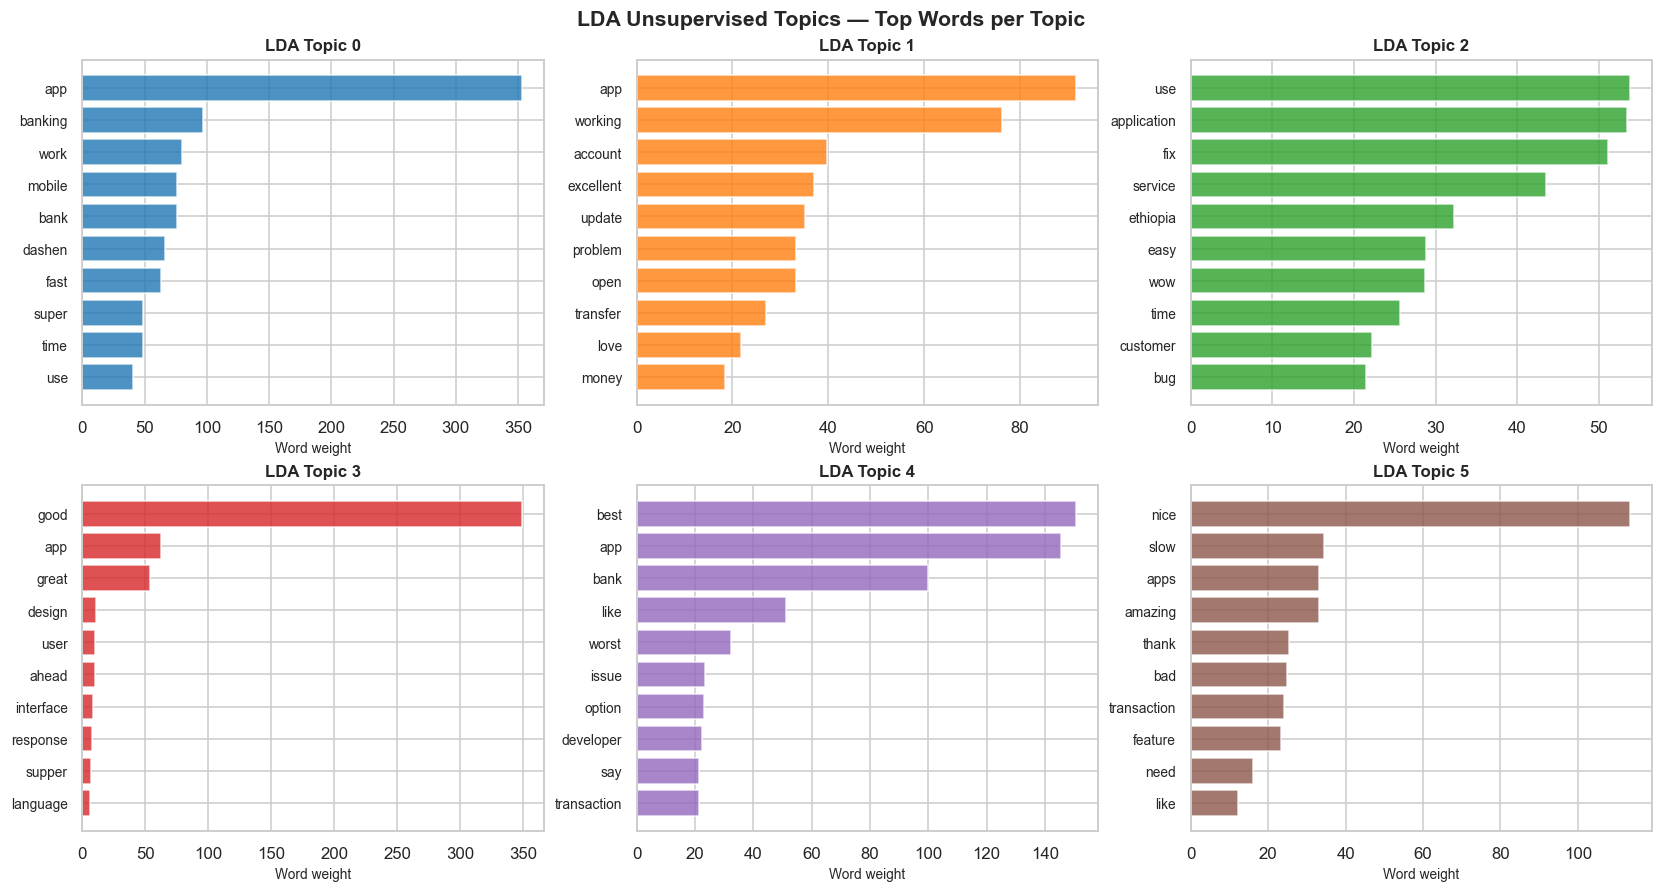

In [34]:
print("Running LDA …")
lda_model, lda_vec, topic_words_df, df_lda = run_lda(
    df, text_col="clean_text", n_topics=6, random_state=42
)

print("\n=== LDA top words per topic ===")
display(topic_words_df)

# Visualise
plot_lda_topics(topic_words_df, lda_model, top_words=10)

=== LDA topic proportions per bank ===


,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5
bank,,,,,,
Bank of Abyssinia,0.302300,0.110900,0.068000,0.214700,0.182500,0.121600
Commercial Bank of Ethiopia,0.195600,0.142600,0.106000,0.250500,0.159000,0.146300
Dashen Bank,0.315400,0.125400,0.080600,0.179200,0.154100,0.145200


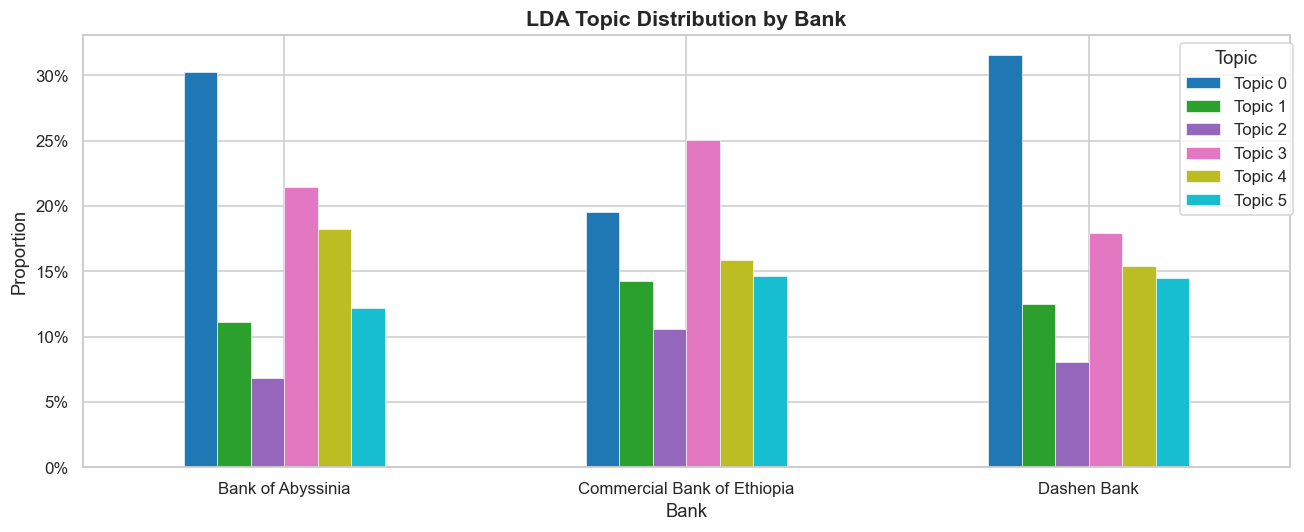

In [35]:
lda_bank_dist = (
    pd.crosstab(df_lda["bank"], df_lda["lda_topic"], normalize="index")
    .round(4)
)
lda_bank_dist.columns = [f"Topic {c}" for c in lda_bank_dist.columns]

print("=== LDA topic proportions per bank ===")
display(lda_bank_dist.style.background_gradient(cmap="Blues", axis=1))

ax = lda_bank_dist.plot(kind="bar", figsize=(12, 5), colormap="tab10",
                         edgecolor="white", linewidth=0.4)
ax.set_title("LDA Topic Distribution by Bank", fontsize=14,
             fontweight="bold")
ax.set_xlabel("Bank")
ax.set_ylabel("Proportion")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Topic", bbox_to_anchor=(1.01, 1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()

In [36]:
print("Comparing supervised theme labels with LDA dominant topics …\n")
compare = (
    df_lda[["bank", "themes", "lda_topic"]]
    .assign(primary_theme=lambda d: d["themes"].str.split(", ").str[0])
    .groupby(["primary_theme", "lda_topic"])
    .size()
    .unstack(fill_value=0)
)
print(compare.to_string())
print("\n(Read as: which LDA topics co-occur most with each supervised theme)")

Comparing supervised theme labels with LDA dominant topics …

lda_topic                  0   1   2    3    4    5
primary_theme                                      
Account Access            34  13   5    0   20   13
App Stability             29  55  18    6   18    5
Customer Support           5   4  10    7    1    5
Feature Requests          12   7   3    2    4    5
Other                    239  86  63  319  162  173
Transaction Performance  107  40  20   14   61   27
UI & Design               26   5  22    9    9    1

(Read as: which LDA topics co-occur most with each supervised theme)


In [37]:
out_path = "data/processed/all_banks_themes.csv"
df_lda.to_csv(out_path, index=False)
print(f"Saved → {out_path}  ({len(df_lda):,} rows)")
print(f"New columns: themes, lda_topic")
print(df_lda[["bank", "review", "themes", "lda_topic"]].head(5).to_string())

Saved → data/processed/all_banks_themes.csv  (1,664 rows)
New columns: themes, lda_topic
                          bank                         review themes  lda_topic
0  Commercial Bank of Ethiopia  best app for financial sector  Other          4
1  Commercial Bank of Ethiopia        it's a good application  Other          3
2  Commercial Bank of Ethiopia                  thank you cbe  Other          5
3  Commercial Bank of Ethiopia                        is good  Other          3
4  Commercial Bank of Ethiopia                            wow  Other          2
